# Machine Learning Pipeline

In [ ]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from keras.callbacks import EarlyStopping
from keras.layers import Dense, Dropout, GRU, LSTM
from keras.models import Sequential


## 1. Konfigurasi Parameter Global

In [ ]:
TICKER = "BBCA.JK"
TARGET_COL = "close"
TRAIN_SIZE_RATIO = 0.80
RANDOM_STATE = 42

# Hiperparameter Deep Learning
WINDOW_SIZE = 30
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001

# Path Penyimpanan Artefak
DATA_PATH = Path(f"artifact/data/{TICKER}.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path(f"{TICKER}.csv")
OUTPUT_DIR = Path("artifact/model")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 2. Data Understanding

### 2.1. Memuat Data

In [ ]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

start_date = df["date"].min().strftime("%Y-%m-%d")
end_date = df["date"].max().strftime("%Y-%m-%d")

print(f"Kode Saham.          : {TICKER}")
print(f"Rentang Tanggal      : {start_date} s.d. {end_date}")
print(f"Total Baris Data     : {len(df)} baris")

Kode Saham.          : BBCA.JK
Rentang Tanggal      : 2021-08-02 s.d. 2026-08-28
Total Baris Data     : 1221 baris


### 2.2. Mengecek Data Hilang

In [ ]:
print(df.isna().sum())

date            0
open            0
high            0
low             0
close           0
volume          0
dividends       0
stock splits    0
ticker          0
dtype: int64


### 2.3. Pengecekan Gap Tanggal

In [ ]:
full_date_range = pd.date_range(start=df["date"].min(), end=df["date"].max(), freq="D")
missing_dates = full_date_range.difference(df["date"])

print(f"Total Tanggal Kalender              : {len(full_date_range)} hari")
print(f"Total Tanggal Transaksi             : {len(df)} hari")
print(f"Total Tanggal yang Bolong           : {len(missing_dates)} hari")

missing_series = pd.Series(missing_dates)
weekend_gaps = missing_series[missing_series.dt.dayofweek >= 5]
weekday_gaps = missing_series[missing_series.dt.dayofweek < 5]

print(f"- Tanggal Bolong Akhir Pekan        : {len(weekend_gaps)} hari")
print(f"- Tanggal Bolong Hari Libur         : {len(weekday_gaps)} hari")

Total Tanggal Kalender              : 1853 hari
Total Tanggal Transaksi             : 1221 hari
Total Tanggal yang Bolong           : 632 hari
- Tanggal Bolong Akhir Pekan        : 528 hari
- Tanggal Bolong Hari Libur         : 104 hari


### 2.4. Visualisasi Tren Harga Historis

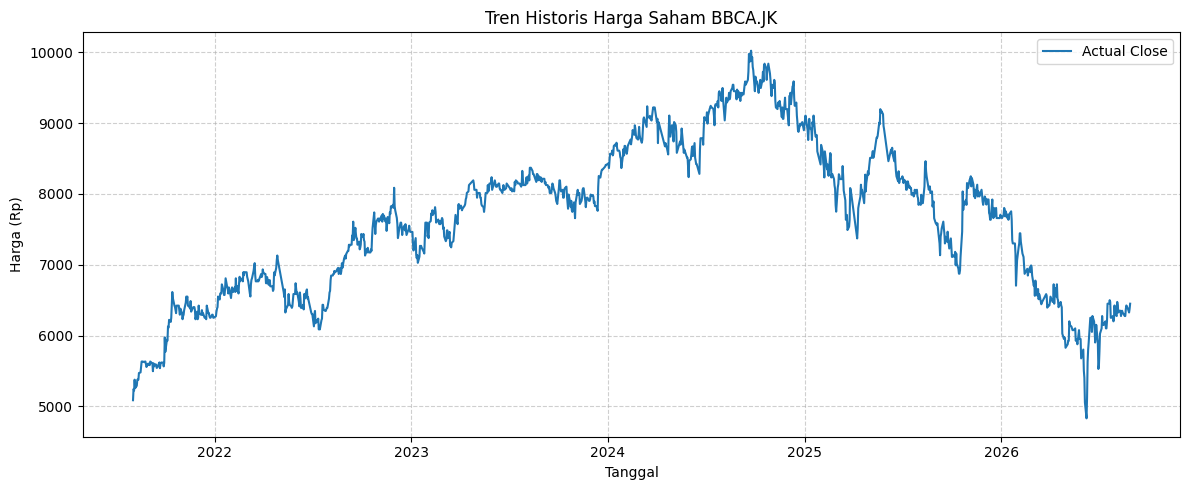

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df[TARGET_COL], label=f"Actual {TARGET_COL.capitalize()}")
plt.title(f"Tren Historis Harga Saham {TICKER}")
plt.xlabel("Tanggal")
plt.ylabel("Harga (Rp)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Data Preparation

### 3.2. Pembagian Data Temporal

In [ ]:
train_len = int(len(df) * TRAIN_SIZE_RATIO)
train_df = df.iloc[:train_len].copy().reset_index(drop=True)
test_df = df.iloc[train_len:].copy().reset_index(drop=True)

print(f"Jumlah Sampel Latih : {len(train_df)}")
print(f"Jumlah Sampel Uji   : {len(test_df)}")

Jumlah Sampel Latih : 976
Jumlah Sampel Uji   : 245


### 3.3. Normalisasi Skala

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[[TARGET_COL]].values)

### 3.4. Sliding Window

In [ ]:
full_series = np.concatenate([train_df[[TARGET_COL]].values, test_df[[TARGET_COL]].values], axis=0)
test_window_inputs = full_series[len(train_df) - WINDOW_SIZE :]
test_scaled = scaler.transform(test_window_inputs)

def create_sliding_window(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size : i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sliding_window(train_scaled, WINDOW_SIZE)
X_test, y_test = create_sliding_window(test_scaled, WINDOW_SIZE)

# Reshape ke format tensor 3D: [samples, time_steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Dimensi Input Tensor Latih : {X_train.shape}")
print(f"Dimensi Input Tensor Uji   : {X_test.shape}")

Dimensi Input Tensor Latih : (946, 30, 1)
Dimensi Input Tensor Uji   : (245, 30, 1)


## 4. Modeling

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=0
)

### 4.1 Long Short-Term Memory (LSTM)

In [ ]:
lstm_model = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16, activation="relu"),
    Dense(units=1)
], name="LSTM_Model")

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mean_squared_error"
)

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - loss: 0.0849 - val_loss: 0.0176
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0113 - val_loss: 0.0042
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0067 - val_loss: 0.0040
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0057 - val_loss: 0.0039
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0052 - val_loss: 0.0038
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0051 - val_loss: 0.0037
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0041 - val_loss: 0.0048
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0043 - val_loss: 0.0036
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 0.0050 - val_loss: 0.0037
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - loss: 0.0050 - val_loss: 0.0040
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0

### 4.2 Gated Recurrent Unit (GRU)

In [ ]:
gru_model = Sequential([
    GRU(units=64, return_sequences=True, input_shape=(WINDOW_SIZE, 1)),
    Dropout(0.2),
    GRU(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16, activation="relu"),
    Dense(units=1)
], name="GRU_Model")

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mean_squared_error"
)

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0570 - val_loss: 0.0136
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0084 - val_loss: 0.0032
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0055 - val_loss: 0.0019
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0045 - val_loss: 0.0037
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0041 - val_loss: 0.0023
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0043 - val_loss: 0.0022
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0034 - val_loss: 0.0022
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0033 - val_loss: 0.0035
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0034 - val_loss: 0.0055
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0031 - val_loss: 0.0019
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0033 - val_loss: 0.0026


## 5. Evaluation

### 5.1. Inferensi Data Uji

In [ ]:
lstm_preds_scaled = lstm_model.predict(X_test, verbose=0)
lstm_forecast_vals = scaler.inverse_transform(lstm_preds_scaled).flatten()

gru_preds_scaled = gru_model.predict(X_test, verbose=0)
gru_forecast_vals = scaler.inverse_transform(gru_preds_scaled).flatten()

y_true = test_df[TARGET_COL].values

### 5.2. Kalkulasi Metrik Evaluasi

In [ ]:
def calculate_metrics(actual, predicted):
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    return {"MAPE": mape, "RMSE": rmse, "R2": r2}

metrics_lstm = calculate_metrics(y_true, lstm_forecast_vals)
metrics_gru = calculate_metrics(y_true, gru_forecast_vals)

metrics_df = pd.DataFrame(
    [metrics_lstm, metrics_gru],
    index=["LSTM", "GRU"]
)

metrics_df

,MAPE,RMSE,R2
LSTM,3.185635,273.933372,0.872301
GRU,2.734461,238.300684,0.903362


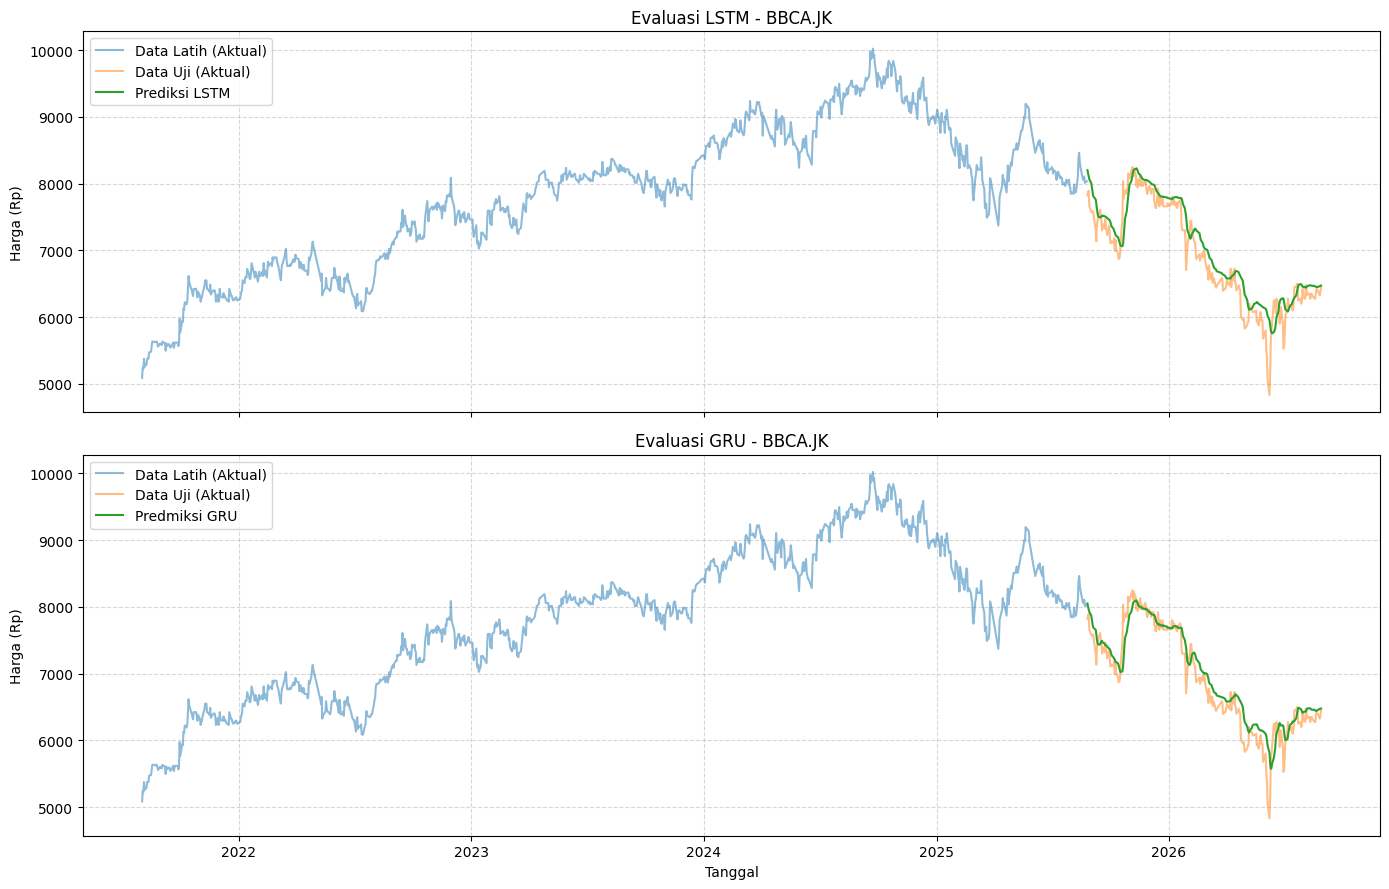

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Subplot 1: LSTM
axes[0].plot(train_df["date"], train_df[TARGET_COL], label="Data Latih (Aktual)", alpha=0.5)
axes[0].plot(test_df["date"], y_true, label="Data Uji (Aktual)", alpha=0.5)
axes[0].plot(test_df["date"], lstm_forecast_vals, label="Prediksi LSTM")
axes[0].set_title(f"Evaluasi LSTM - {TICKER}")
axes[0].set_ylabel("Harga (Rp)")
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Subplot 2: GRU
axes[1].plot(train_df["date"], train_df[TARGET_COL], label="Data Latih (Aktual)", alpha=0.5)
axes[1].plot(test_df["date"], y_true, label="Data Uji (Aktual)", alpha=0.5)
axes[1].plot(test_df["date"], gru_forecast_vals, label="Predmiksi GRU")
axes[1].set_title(f"Evaluasi GRU - {TICKER}")
axes[1].set_xlabel("Tanggal")
axes[1].set_ylabel("Harga (Rp)")
axes[1].legend(loc="upper left")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Penyimpanan Model dan Artefak


In [ ]:
# Simpan Model Deep Learning (Keras format)
lstm_path = OUTPUT_DIR / f"{TICKER}_LSTM.keras"
gru_path = OUTPUT_DIR / f"{TICKER}_GRU.keras"

lstm_model.save(lstm_path)
gru_model.save(gru_path)
print(f"Model LSTM berhasil disimpan ke : {lstm_path}")
print(f"Model GRU berhasil disimpan ke  : {gru_path}")

# Simpan Model ke Format ONNX (Optimal untuk In-Browser Web Runtime)
try:
    import tf2onnx
    lstm_onnx_path = OUTPUT_DIR / f"{TICKER}_LSTM.onnx"
    gru_onnx_path = OUTPUT_DIR / f"{TICKER}_GRU.onnx"

    @tf.function(input_signature=[tf.TensorSpec((None, int(WINDOW_SIZE), 1), tf.float32, name="input")])
    def lstm_serve(x):
        return {"output": lstm_model(x)}

    @tf.function(input_signature=[tf.TensorSpec((None, int(WINDOW_SIZE), 1), tf.float32, name="input")])
    def gru_serve(x):
        return {"output": gru_model(x)}

    tf2onnx.convert.from_function(
        lstm_serve,
        input_signature=[tf.TensorSpec((None, int(WINDOW_SIZE), 1), tf.float32, name="input")],
        output_path=str(lstm_onnx_path)
    )
    tf2onnx.convert.from_function(
        gru_serve,
        input_signature=[tf.TensorSpec((None, int(WINDOW_SIZE), 1), tf.float32, name="input")],
        output_path=str(gru_onnx_path)
    )
    print(f"Model LSTM (ONNX) berhasil disimpan ke : {lstm_onnx_path}")
    print(f"Model GRU (ONNX) berhasil disimpan ke  : {gru_onnx_path}")
except Exception as e:
    print(f"Peringatan ekspor ONNX: {e}")

# Simpan Normalizer (MinMaxScaler)
scaler_path = OUTPUT_DIR / f"{TICKER}_scaler.pkl"
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler berhasil disimpan ke     : {scaler_path}")

# Simpan Metadata dan Metrik Evaluasi
metrics_dict = {
    "LSTM": {k: float(v) for k, v in metrics_lstm.items()},
    "GRU": {k: float(v) for k, v in metrics_gru.items()}
}
best_variant = "LSTM" if metrics_lstm["RMSE"] <= metrics_gru["RMSE"] else "GRU"

metadata = {
    "ticker": TICKER,
    "target_col": TARGET_COL,
    "window_size": int(WINDOW_SIZE),
    "batch_size": int(BATCH_SIZE),
    "epochs": int(EPOCHS),
    "learning_rate": float(LEARNING_RATE),
    "train_size_ratio": float(TRAIN_SIZE_RATIO),
    "best_model": best_variant,
    "metrics": metrics_dict
}

metadata_path = OUTPUT_DIR / f"{TICKER}_metrics.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Metadata berhasil disimpan ke   : {metadata_path}")
